In [ ]:
!pip install gymnasium stable-baselines3 numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 2.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv


def wrap_pi(angle):
    """Wrap angle to (-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


class UnicycleTargetEnv(gym.Env):
    """
    Unicycle kinematics with acceleration control:
        x_dot     = v cos(theta)
        y_dot     = v sin(theta)
        theta_dot = omega
        v_dot     = accel

    Actions: [omega, accel]
        omega  -- angular velocity  in [-omega_max,  omega_max]
        accel  -- linear accel      in [-accel_max,  accel_max]
        v is clamped to [v_min, v_max] after each update.

    Observation: [dx, dy, cos(theta), sin(theta), cos(phi), sin(phi),
                  dist, heading_error, v]
      where phi = bearing to target

    Control cost weights:
        omega_cost  -- penalty weight for (omega / omega_max)^2
        accel_cost  -- penalty weight for (accel / accel_max)^2
        Increase accel_cost relative to omega_cost to discourage
        large speed changes vs. large turning.
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        dt=0.1,
        v_init=1.0,
        v_min=0.0,
        v_max=2.0,
        omega_max=2.5,
        accel_max=2.0,
        world_size=10.0,
        target_radius=0.25,
        max_steps=300,
        # --- tunable cost weights ---
        omega_cost=0.01,   # cost on (omega / omega_max)^2
        accel_cost=0.01,   # cost on (accel / accel_max)^2  <-- raise this to penalise speed changes more
        seed=None,
    ):
        super().__init__()
        self.dt            = float(dt)
        self.v_init        = float(v_init)
        self.v_min         = float(v_min)
        self.v_max         = float(v_max)
        self.omega_max     = float(omega_max)
        self.accel_max     = float(accel_max)
        self.world_size    = float(world_size)
        self.target_radius = float(target_radius)
        self.max_steps     = int(max_steps)
        self.omega_cost    = float(omega_cost)
        self.accel_cost    = float(accel_cost)

        self.np_random = np.random.default_rng(seed)

        # ---- Action space: [omega, accel] ----
        self.action_space = spaces.Box(
            low=np.array([-self.omega_max, -self.accel_max], dtype=np.float32),
            high=np.array([ self.omega_max,  self.accel_max], dtype=np.float32),
            dtype=np.float32,
        )

        # ---- Observation space (9-dim, includes v) ----
        obs_low = np.array(
            [-2*self.world_size, -2*self.world_size,
             -1, -1, -1, -1,
             0.0, -np.pi,
             self.v_min],
            dtype=np.float32,
        )
        obs_high = np.array(
            [ 2*self.world_size,  2*self.world_size,
              1,  1,  1,  1,
              2*np.sqrt(2)*self.world_size, np.pi,
              self.v_max],
            dtype=np.float32,
        )
        self.observation_space = spaces.Box(obs_low, obs_high, dtype=np.float32)

        self.x         = None
        self.y         = None
        self.theta     = None
        self.v         = None
        self.tx        = None
        self.ty        = None
        self.steps     = 0
        self.prev_dist = None

    def _get_obs(self):
        dx   = self.tx - self.x
        dy   = self.ty - self.y
        dist = np.sqrt(dx*dx + dy*dy)

        phi           = np.arctan2(dy, dx)
        heading_error = wrap_pi(phi - self.theta)

        obs = np.array(
            [
                dx,
                dy,
                np.cos(self.theta),
                np.sin(self.theta),
                np.cos(phi),
                np.sin(phi),
                dist,
                heading_error,
                self.v,
            ],
            dtype=np.float32,
        )
        return obs

    def reset(
            self,
            seed=None,
            options=None,
            start=None,
            target=None,
            theta0=None,
            v0=None,
        ):
            super().reset(seed=seed)

            if seed is not None:
                self.np_random = np.random.default_rng(seed)

            if start is not None:
                self.x, self.y = start
            else:
                self.x = self.np_random.uniform(-self.world_size, self.world_size)
                self.y = self.np_random.uniform(-self.world_size, self.world_size)

            if theta0 is not None:
                self.theta = theta0
            else:
                self.theta = self.np_random.uniform(-np.pi, np.pi)

            if v0 is not None:
                self.v = float(v0)
            else:
                self.v = float(self.v_init)

            if target is not None:
                self.tx, self.ty = target
            else:
                for _ in range(100):
                    self.tx = self.np_random.uniform(-self.world_size, self.world_size)
                    self.ty = self.np_random.uniform(-self.world_size, self.world_size)
                    if (self.tx - self.x)**2 + (self.ty - self.y)**2 > (0.5*self.world_size)**2:
                        break

            self.steps = 0
            obs = self._get_obs()
            self.prev_dist = float(obs[6])
            return obs, {}

    def step(self, action):
        self.steps += 1

        omega = float(np.clip(action[0], -self.omega_max, self.omega_max))
        accel = float(np.clip(action[1], -self.accel_max,  self.accel_max))

        # --- KINEMATICS ---
        self.x     += self.dt * self.v * np.cos(self.theta)
        self.y     += self.dt * self.v * np.sin(self.theta)
        self.theta  = wrap_pi(self.theta + self.dt * omega)
        self.v      = float(np.clip(self.v + self.dt * accel,
                                    self.v_min, self.v_max))

        obs           = self._get_obs()
        dist          = float(obs[6])
        heading_error = float(obs[7])

        # --- REWARD ---
        progress = self.prev_dist - dist

        align_penalty = 0.05 * abs(heading_error)

        # Separate, independently-tunable control costs
        omega_penalty = self.omega_cost * (omega / self.omega_max) ** 2
        accel_penalty = self.accel_cost * (accel / self.accel_max) ** 2

        reward = 5.0 * progress - align_penalty - omega_penalty - accel_penalty

        terminated = dist <= self.target_radius
        truncated  = self.steps >= self.max_steps

        if terminated:
            reward += 10.0

        self.prev_dist = dist
        info = {
            "dist": dist,
            "heading_error": heading_error,
            "omega": omega,
            "accel": accel,
            "v": self.v,
        }
        return obs, reward, terminated, truncated, info


# ============================================================
# COST WEIGHT GUIDE
#
#   omega_cost  -- penalises turning effort
#   accel_cost  -- penalises speed changes
#
#   Both penalties are normalised:  cost * (action / action_max)^2
#   so the scale is always in [0, cost].
#
#   Examples:
#     omega_cost=0.01, accel_cost=0.01  --> equal cost (baseline)
#     omega_cost=0.01, accel_cost=0.10  --> speed changes 10x more expensive
#     omega_cost=0.01, accel_cost=0.50  --> agent strongly prefers constant speed
# ============================================================

def train(
    omega_cost=0.10,
    accel_cost=0.01,   # <-- raise this to penalise speed changes more
):
    env = UnicycleTargetEnv(
        dt=0.1,
        v_init=1.0,
        v_min=0.0,
        v_max=2.0,
        omega_max=3.0,
        accel_max=2.0,
        world_size=10.0,
        target_radius=0.3,
        max_steps=300,
        omega_cost=omega_cost,
        accel_cost=accel_cost,
        seed=0,
    )

    check_env(env, warn=True)
    vec_env = DummyVecEnv([lambda: env])

    model = PPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        n_steps=2048,
        batch_size=256,
        gamma=0.99,
        gae_lambda=0.95,
        learning_rate=3e-4,
        ent_coef=0.0,
        clip_range=0.2,
        device="auto",
    )

    model.learn(total_timesteps=300_000)
    model.save("ppo_unicycle_accel")
    print("Saved model to ppo_unicycle_accel.zip")


def test(episodes=5):
    env   = UnicycleTargetEnv(seed=123)
    model = PPO.load("ppo_unicycle_accel")

    for ep in range(episodes):
        obs, _ = env.reset()
        total_r = 0.0
        for t in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            total_r += r
            if term or trunc:
                print(f"Episode {ep}: steps={t+1}, success={term}, "
                      f"dist={info['dist']:.3f}, v={info['v']:.2f}, "
                      f"return={total_r:.2f}")
                break


if __name__ == "__main__":
    train(omega_cost=0.01, accel_cost=0.10)
    test()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/env_checker.py:507: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1511 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1334        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006669147 |
|    clip_fraction        | 0.0642      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.84       |
|    explained_variance   | 0.00975     |
|    learning_rate        | 0.0003      |
|    loss                 | 22.9        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00759    |
|    std                  | 1           |
|    value_loss           | 65.5        |
-----------------

Episode 1: Steps=39, Success=True, Final Distance=0.104, Final v=2.00, Return=47.35


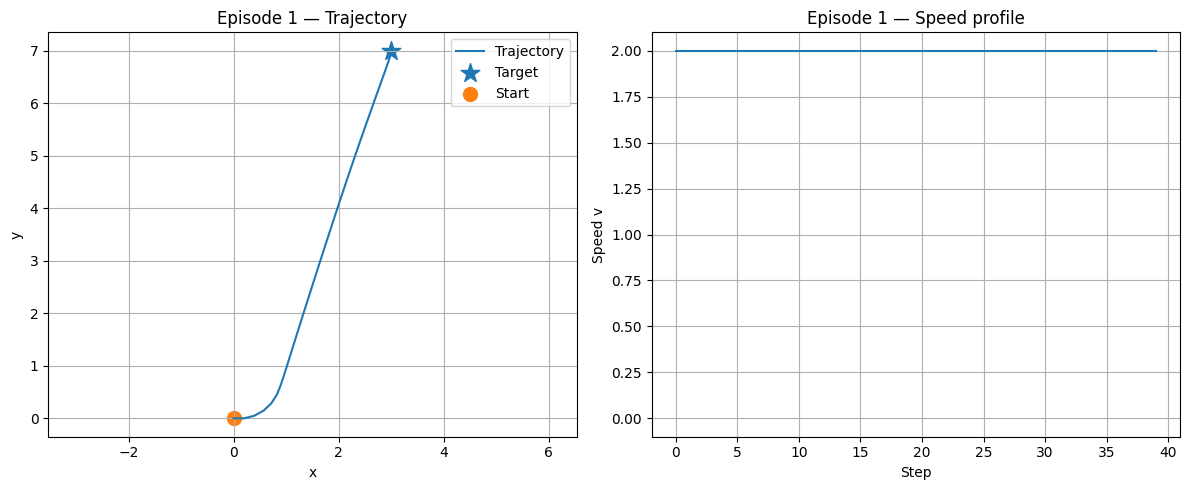

Episode 2: Steps=39, Success=True, Final Distance=0.104, Final v=2.00, Return=47.35


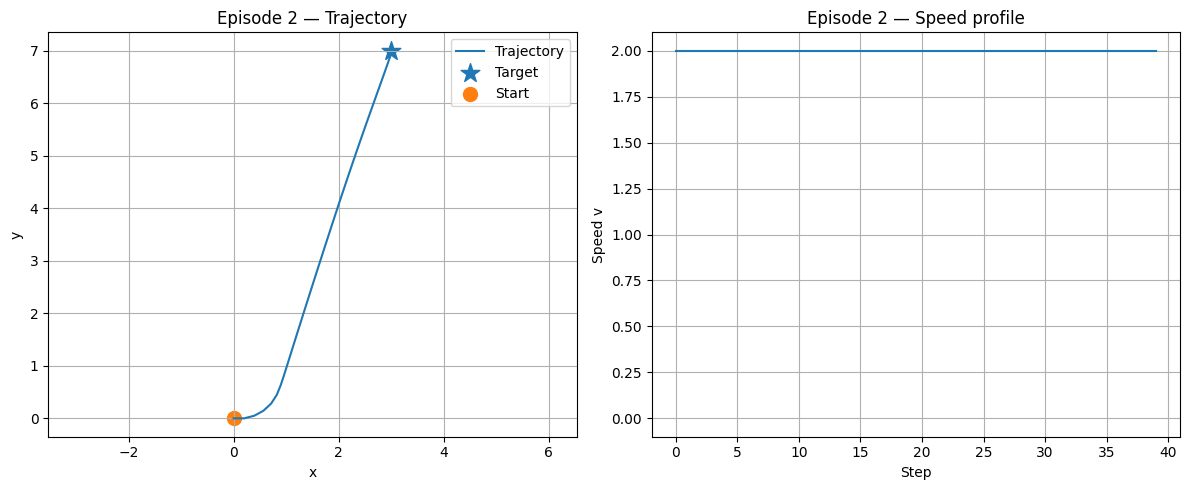

Episode 3: Steps=39, Success=True, Final Distance=0.104, Final v=2.00, Return=47.35


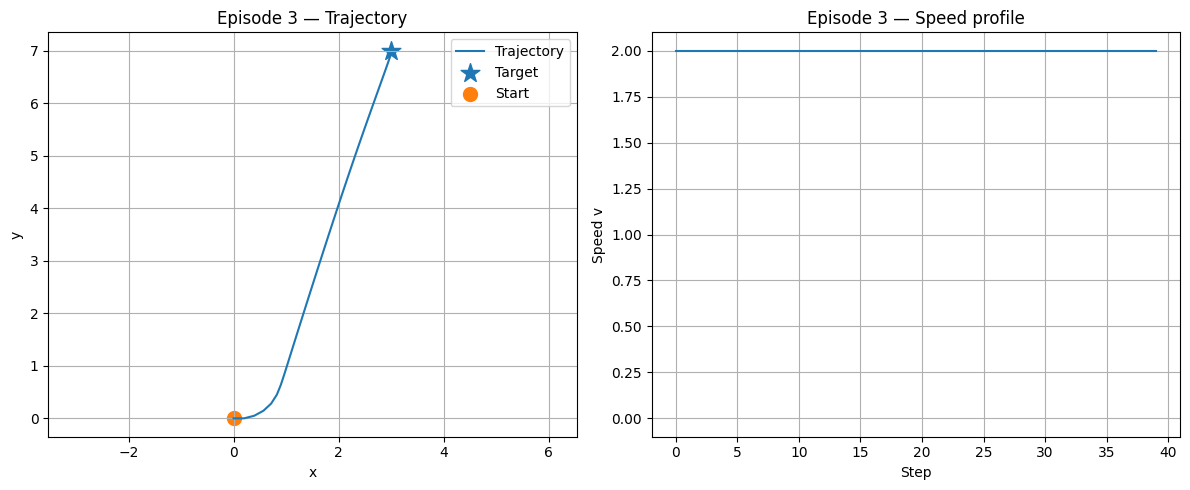

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO


def run_test(model_path="ppo_unicycle_accel.zip", episodes=3):
    model = PPO.load(model_path)
    env   = UnicycleTargetEnv(seed=42)

    for ep in range(episodes):
        obs, _ = env.reset(
            start=(0.0, 0.0),
            target=(3.0, 7.0),
            theta0=0.0,
            v0 = 2.0
        )

        xs, ys = [env.x], [env.y]
        vs     = [env.v]
        total_reward = 0

        for step in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)

            xs.append(env.x)
            ys.append(env.y)
            vs.append(env.v)
            total_reward += reward

            if terminated or truncated:
                break

        print(
            f"Episode {ep+1}: "
            f"Steps={step+1}, "
            f"Success={terminated}, "
            f"Final Distance={info['dist']:.3f}, "
            f"Final v={info['v']:.2f}, "
            f"Return={total_reward:.2f}"
        )

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        ax1.plot(xs, ys, label="Trajectory")
        ax1.scatter(env.tx, env.ty, marker="*", s=200, label="Target")
        ax1.scatter(xs[0], ys[0], marker="o", s=100, label="Start")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y")
        ax1.set_title(f"Episode {ep+1} — Trajectory")
        ax1.legend()
        ax1.axis("equal")
        ax1.grid()

        ax2.plot(vs)
        ax2.set_xlabel("Step")
        ax2.set_ylabel("Speed v")
        ax2.set_title(f"Episode {ep+1} — Speed profile")
        ax2.set_ylim(env.v_min - 0.1, env.v_max + 0.1)
        ax2.grid()

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    run_test()